In [ ]:
# SHAZAM SHM MODELS 
# Este script aplica tres enfoques complementarios para analizar las mutaciones somáticas 
# en tu repertorio: primero calcula la carga mutacional global comparando cada secuencia 
# completa contra su germline, luego evalúa la distribución de mutaciones por 
# subregiones (CDR y FWR según definiciones IMGT) para distinguir entre regiones de unión
# y estructurales, y finalmente clasifica las mutaciones según propiedades fisicoquímicas
# de los aminoácidos (carga, polaridad, hidrofobicidad o volumen) para estimar su impacto
# funcional

In [10]:

library(shazam)
library(alakazam)
library(readr)
library(dplyr)
library(ggplot2)


In [32]:
# MUTATION ANALYSIS SHAZAM
# 1. Cargar tu archivo
archivo_clones <- "../data/output/repertorio_E_insilico_1000_seqs_clone-pass.tsv"
clones <- read_tsv(archivo_clones) %>%
  mutate(sample_id = "repertorio_simulado")

# 2. Mutaciones globales (toda la secuencia)
mut_global <- observedMutations(
  clones,
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=NULL,   # toda la secuencia
  frequency=TRUE
)

# 3. Mutaciones por subregión (CDR/FWR según IMGT)
mut_regions <- observedMutations(
  clones,
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V_BY_REGIONS,   # esquema IMGT con CDR/FWR
  frequency=TRUE
)


# Mutaciones globales
db_all <- mut_global[, c("mu_freq_seq_r","mu_freq_seq_s")]

# Mutaciones en CDR1 y CDR2 (R y S)
cdr_mutations <- mut_regions[, c("mu_freq_cdr1_r","mu_freq_cdr1_s",
                                 "mu_freq_cdr2_r","mu_freq_cdr2_s")]

# Mutaciones en FWR1–3 (R y S)
fwr_mutations <- mut_regions[, c("mu_freq_fwr1_r","mu_freq_fwr1_s",
                                 "mu_freq_fwr2_r","mu_freq_fwr2_s",
                                 "mu_freq_fwr3_r","mu_freq_fwr3_s")]

# Combinar todo en un solo objeto
db_selected <- cbind(db_all, cdr_mutations, fwr_mutations)

# Revisar primeras filas
head(db_selected)



Rows: 1000 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


,mu_freq_seq_r,mu_freq_seq_s,mu_freq_cdr1_r,mu_freq_cdr1_s,mu_freq_cdr2_r,mu_freq_cdr2_s,mu_freq_fwr1_r,mu_freq_fwr1_s,mu_freq_fwr2_r,mu_freq_fwr2_s,mu_freq_fwr3_r,mu_freq_fwr3_s
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.011080332,0.005540166,0.00000000,0,0.04166667,0.04166667,0.01333333,0.01333333,0.00000000,0,0.01754386,0.00000000
2,0.011267606,0.000000000,0.04166667,0,0.00000000,0.00000000,0.00000000,0.00000000,0.01960784,0,0.00877193,0.00000000
3,0.005555556,0.008333333,0.00000000,0,0.00000000,0.00000000,0.02666667,0.01333333,0.00000000,0,0.00000000,0.01754386
4,0.021917808,0.002739726,0.00000000,0,0.08333333,0.00000000,0.04000000,0.01333333,0.00000000,0,0.00877193,0.00000000
5,0.005555556,0.002777778,0.00000000,0,0.00000000,0.00000000,0.00000000,0.01333333,0.00000000,0,0.01754386,0.00000000
6,0.016620499,0.008310249,0.00000000,0,0.08333333,0.00000000,0.02666667,0.00000000,0.01960784,0,0.00877193,0.00877193


In [33]:
readr::write_tsv(db_all, "../results/shm_models/mutation_model_E_1000seqs.tsv")

In [34]:
# BASELINE MODEL
# 1. Cargar archivo
archivo_clones <- "../data/output/repertorio_E_insilico_1000_seqs_clone-pass.tsv"
db <- read_tsv(archivo_clones) %>%
  mutate(
    sample_id = "repertorio_naive",
    clone_id = as.character(clone_id)
  ) %>%
  filter(!is.na(clone_id))

# 2. Asignar IGHM si c_call está vacío
if (all(is.na(db$c_call))) {
  db$c_call <- "IGHM"
}

# 3. Colapsar clones
clones <- collapseClones(
  db,
  cloneColumn="clone_id",
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V,
  method="thresholdedFreq",
  minimumFrequency=0.3,
  includeAmbiguous=FALSE,
  breakTiesStochastic=FALSE,
  nproc=1
)

# 4. Calcular selección
baseline <- calcBaseline(
  clones,
  testStatistic="focused",
  regionDefinition=IMGT_V,
  nproc=1
)

# 5. Mensaje pipeline con pdfs o no
if (length(baseline) == 0) {
  message("Pipeline ejecutado correctamente. No hay PDFs de selección porque el repertorio naïve no tiene mutaciones.")
} else {
  message("Pipeline ejecutado correctamente. Hay resultados de selección disponibles.")
}

grouped <- groupBaseline(baseline, groupBy="sample_id")

# Chequear que grouped tenga datos y la columna sample_id
if (!is.null(grouped) && nrow(grouped) > 0 && "sample_id" %in% colnames(grouped)) {
  plotBaselineSummary(grouped, idColumn="sample_id")
  plotBaselineDensity(grouped, idColumn="sample_id")
} else {
  message("No hay PDFs de selección → no se genera gráfico.")
}





Rows: 1000 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
calcBaseline will calculate observed and expected mutations for clonal_sequence using clonal_germline as a reference.



Calculating BASELINe probability density functions...


Pipeline ejecutado correctamente. Hay resultados de selecci<U+00F3>n disponibles.



Grouping BASELINe probability density functions...
Calculating BASELINe statistics...


No hay PDFs de selecci<U+00F3>n <U+2192> no se genera gr<U+00E1>fico.



In [ ]:
write_tsv(grouped, "../results/shm_models/repertorio_C_1000seq_baseline.tsv")

ERROR: Error in write_delim(x, file, delim = "\t", na = na, append = append, : is.data.frame(x) is not TRUE


Rows: 1000 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in createMutabilityMatrix(db, sub_mat, model = model, sequenceColumn = sequenceColumn, :
"Insufficient number of mutations to infer some 5-mers. Filled with 0. "
Pipeline ejecutado correctamente. Modelo de targeting disponible.



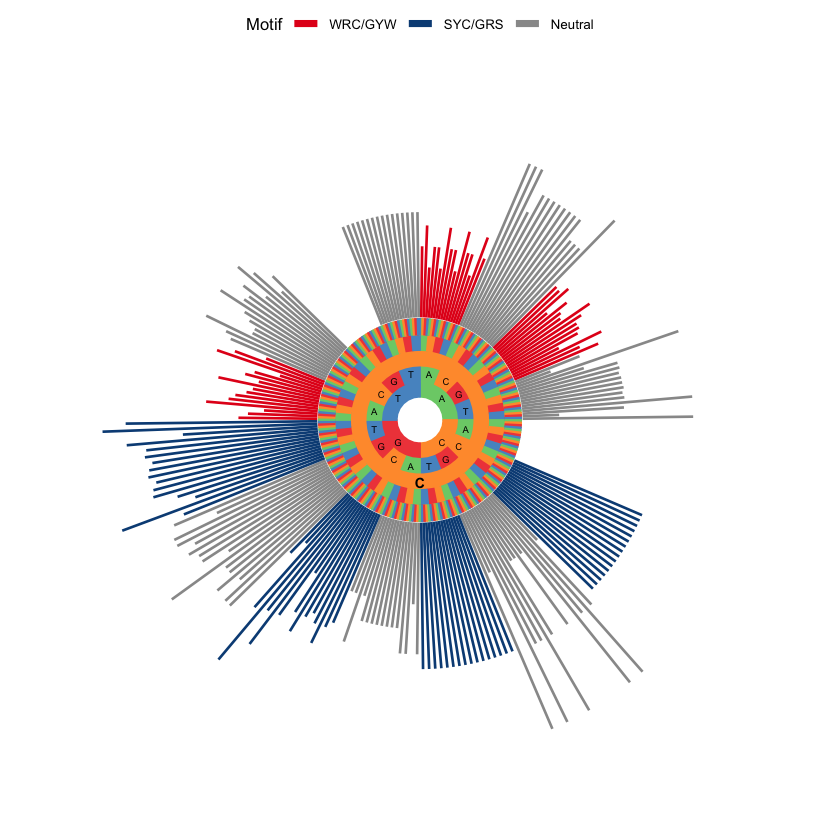

In [35]:
# TARGETING MODEL
# 1. Cargar archivo
archivo_clones <- "../data/output/repertorio_E_insilico_1000_seqs_clone-pass.tsv"
db <- read_tsv(archivo_clones) %>%
  mutate(
    sample_id = "repertorio_naive",
    clone_id = as.character(clone_id)
  ) %>%
  filter(!is.na(clone_id))

# 2. Asignar IGHM si c_call está vacío
if (all(is.na(db$c_call))) {
  db$c_call <- "IGHM"
}

# 3. Colapsar clones (igual que en baseline)
clones <- collapseClones(
  db,
  cloneColumn="clone_id",
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V,
  method="thresholdedFreq",
  minimumFrequency=0.6,
  includeAmbiguous=FALSE,
  breakTiesStochastic=FALSE,
  nproc=1
)

# 4. Crear modelo de targeting (mutabilidad + sustitución)
targeting_model <- createTargetingModel(
  clones,
  model="s",                        # usar mutaciones silenciosas
  sequenceColumn="clonal_sequence",
  germlineColumn="clonal_germline",
  vCallColumn="v_call"
)

# 5. Mensaje pipeline
if (is.null(targeting_model) || length(targeting_model) == 0) {
  message("Pipeline ejecutado correctamente. No se generó modelo de targeting (no hay mutaciones suficientes).")
} else {
  message("Pipeline ejecutado correctamente. Modelo de targeting disponible.")
}

# 6. Visualización de mutabilidad (ejemplo con nucleótido C)
if (!is.null(targeting_model) && length(targeting_model) > 0) {
  plotMutability(targeting_model, nucleotides="C", style="hedgehog")
  
  # 7. Calcular matriz de distancias
  targeting_dist <- calcTargetingDistance(targeting_model)
} else {
  message("No se generan gráficos ni distancias → no hay modelo de targeting válido.")
}


In [36]:
# Exportar solo la matriz de distancias del targeting
write_tsv(as_tibble(targeting_dist), "../results/shm_models/targeting_distances_E_1000seqs.tsv")

Rows: 1000 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in createMutabilityMatrix(db, sub_mat, model = model, sequenceColumn = sequenceColumn, :
"Insufficient number of mutations to infer some 5-mers. Filled with 0. "
Pipeline ejecutado correctamente. Modelo de targeting disponible.



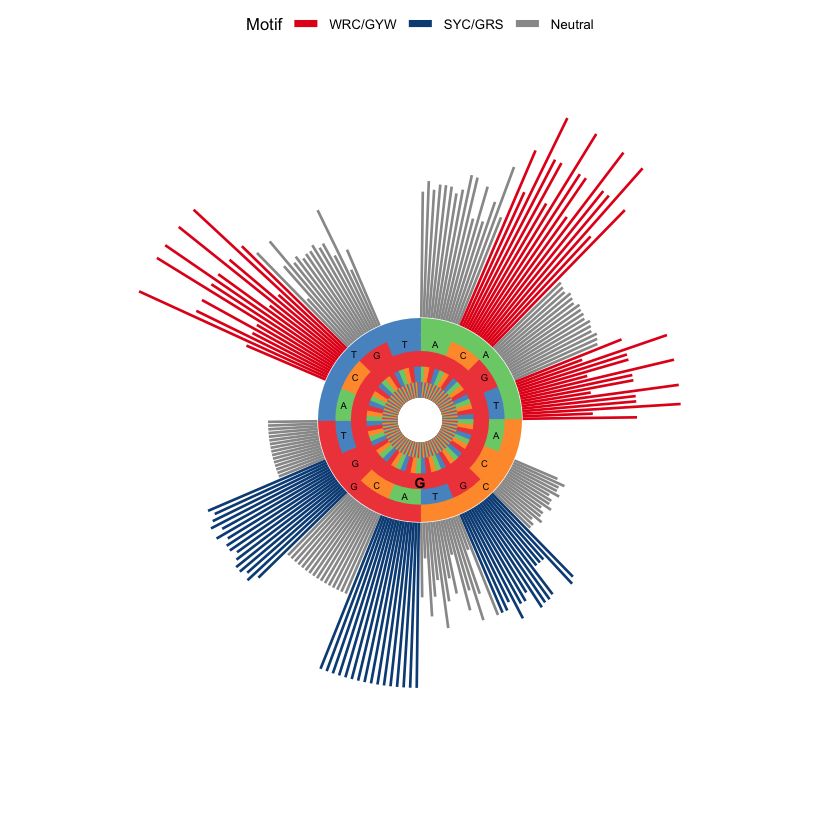

In [37]:
# TARGETING MODEL
# 1. Cargar archivo
archivo_clones <- "../data/output/repertorio_E_insilico_1000_seqs_clone-pass.tsv"
db <- read_tsv(archivo_clones) %>%
  mutate(
    sample_id = "repertorio_naive",
    clone_id = as.character(clone_id)
  ) %>%
  filter(!is.na(clone_id))

# 2. Asignar IGHM si c_call está vacío
if (all(is.na(db$c_call))) {
  db$c_call <- "IGHM"
}

# 3. Colapsar clones (igual que en baseline)
clones <- collapseClones(
  db,
  cloneColumn="clone_id",
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V,
  method="thresholdedFreq",
  minimumFrequency=0.6,
  includeAmbiguous=FALSE,
  breakTiesStochastic=FALSE,
  nproc=1
)
# 4. Crear modelo de targeting (mutabilidad + sustitución)
targeting_model <- createTargetingModel(
  clones,
  model="s",                        # usar mutaciones silenciosas
  sequenceColumn="clonal_sequence",
  germlineColumn="clonal_germline",
  vCallColumn="v_call"
)

# 5. Mensaje pipeline
if (is.null(targeting_model) || length(targeting_model) == 0) {
  message("Pipeline ejecutado correctamente. No se generó modelo de targeting (no hay mutaciones suficientes).")
} else {
  message("Pipeline ejecutado correctamente. Modelo de targeting disponible.")
}

# 6. Visualización de mutabilidad (ejemplo con nucleótido C)
if (!is.null(targeting_model) && length(targeting_model) > 0) {
  plotMutability(targeting_model, nucleotides="G", style="hedgehog")
  
  # 7. Calcular matriz de distancias
  targeting_dist <- calcTargetingDistance(targeting_model)
} else {
  message("No se generan gráficos ni distancias → no hay modelo de targeting válido.")
}

In [38]:
# Exportar solo la matriz de distancias del targeting
write_tsv(as_tibble(targeting_dist), "../results/shm_models/targeting_distances_E_1000seqsG.tsv")